### EDA

In [12]:
import pandas as pd
import numpy as np


def comprehensive_eda_report(file_path, label_col, missing_threshold=0):

    # Load data
    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print(f"读取文件失败: {e}")
        return

    # 1. Basic info
    n_samples, n_features = df.shape

    # 2. Missing value analysis
    missing_data = df.isnull().mean()  # Missing proportion per column
    missing_counts = df.isnull().sum() # Absolute missing count per column

    # Filter columns with severe missing values
    severe_missing = missing_data[missing_data > missing_threshold]
    
    # 3. Feature type
    # Binary
    binary_cols = [col for col in df.columns if df[col].nunique() == 2]
    # Numerical
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c not in binary_cols]
    # Categorical
    cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    cat_cols = [c for c in cat_cols if c not in binary_cols]

    print(f"* **Total samples**: {n_samples}")
    print(f"* **Total features**: {n_features}")
    print(f"* **Memory usage**: {df.memory_usage().sum() / 1024**2:.2f} MB")
    print("-" * 30)

    print(f"## 2. Feature type statistics")
    print(f"* **Numerical**: {len(num_cols)} columns")
    print(f"* **Categorical**: {len(cat_cols)} columns")
    print(f"* **Binary**: {len(binary_cols)} columns")
    print("-" * 30)

    print(f"## 3. Missing value analysis (Threshold: {missing_threshold:.0%})")
    print(f"* **Average missing rate**: {missing_data.mean():.2%}")
    if not severe_missing.empty:
        print(f"* **Severe missing columns ({len(severe_missing)}个)**:")
        print("| Feature Name | Missing Proportion | Missing Count |")
        print("| :--- | :--- | :--- |")
        for col in severe_missing.index:
            print(f"| {col} | {missing_data[col]:.2%} | {missing_counts[col]} |")
    else:
        print("* **Conclusion**: No severely missing columns.")
    print("-" * 30)

    # 4. Label distribution and imbalance check
    if label_col in df.columns:
        print(f"## 4. Label distribution: {label_col}")
        counts = df[label_col].value_counts()
        pcts = df[label_col].value_counts(normalize=True)
        
        print("| Class | Sample Count | Percentage |")
        print("| :--- | :--- | :--- |")
        for idx in counts.index:
            print(f"| {idx} | {counts[idx]} | {pcts[idx]:.2%} |")
        
        is_imbalanced = pcts.min() < 0.1
        status = "**Severe imbalance ⚠️**" if is_imbalanced else "Relatively balanced"
        print(f"\n* **Balance evaluation**: {status}")
    else:
        print(f"## 4. Label analysis: Column '{label_col}' not found")

# 调用示例
comprehensive_eda_report('Assignment1_mimic dataset.csv', 'icu_death_flag')

* **Total samples**: 65365
* **Total features**: 131
* **Memory usage**: 65.33 MB
------------------------------
## 2. Feature type statistics
* **Numerical**: 123 columns
* **Categorical**: 5 columns
* **Binary**: 3 columns
------------------------------
## 3. Missing value analysis (Threshold: 0%)
* **Average missing rate**: 59.25%
* **Severe missing columns (120个)**:
| Feature Name | Missing Proportion | Missing Count |
| :--- | :--- | :--- |
| insurance | 2.08% | 1362 |
| language | 0.54% | 355 |
| marital_status | 10.25% | 6699 |
| heart_rate_min | 0.11% | 73 |
| heart_rate_max | 0.11% | 73 |
| heart_rate_mean | 0.11% | 73 |
| sbp_min | 0.15% | 98 |
| sbp_max | 0.15% | 98 |
| sbp_mean | 0.15% | 98 |
| dbp_min | 0.15% | 98 |
| dbp_max | 0.15% | 98 |
| dbp_mean | 0.15% | 98 |
| mbp_min | 0.18% | 118 |
| mbp_max | 0.18% | 118 |
| mbp_mean | 0.18% | 118 |
| resp_rate_min | 0.30% | 193 |
| resp_rate_max | 0.30% | 193 |
| resp_rate_mean | 0.30% | 193 |
| temperature_min | 3.15% | 2057 |

### Data Preprocessing

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer


TARGET_COL = 'icu_death_flag'

CAT_COLS = ['gender', 'race', 'marital_status', 'first_careunit', 'insurance', 'language']


# ============================================================
# 1. load data
# ============================================================

df = pd.read_csv('Assignment1_mimic dataset.csv')


# ============================================================
# 2. Column filtering based on missing values (>50% threshold)
# ============================================================

missing_ratio = df.isnull().mean()
cols_to_drop  = missing_ratio[missing_ratio > 0.5].index.tolist()

print(f"* Original number of features: {df.shape[1]}")
print(f"* Features with missing rate > 50%: {len(cols_to_drop)}")
print(f"* Features to be dropped: {cols_to_drop}")

df_filtered = df.drop(columns=cols_to_drop)
df_filtered.to_csv('df_filtered.csv', index=False)

print(f"\n* Remaining features after filtering: {df_filtered.shape[1]}")

if TARGET_COL in df_filtered.columns:
    print(f"Target variable '{TARGET_COL}' has been retained.")

# ============================================================
# 3. Categorical feature missing value handling (fill with 'Unknown')
# ============================================================

print("\n## Processing categorical features...")
df_filtered[CAT_COLS] = df_filtered[CAT_COLS].fillna("Unknown")
df_filtered.to_csv('df_cate_filled.csv', index=False)

for col in CAT_COLS:
    if col in df_filtered.columns:
        null_count = df_filtered[col].isnull().sum()
        print(f"* Feature {col}: Missing values have been filled" if null_count == 0 else f"⚠️ {col} still has missing values")


# ============================================================
# 4. DATA SPLIT: Train/Test (7:3) with stratification on target variable
# ============================================================

X = df_filtered.drop(columns=[TARGET_COL])
y = df_filtered[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)


X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f"* Training set size (X_train): {X_train.shape[0]} rows | Death count: {y_train.sum()} ({y_train.mean():.2%})")
print(f"* Test set size (X_test):  {X_test.shape[0]} rows | Death count: {y_test.sum()} ({y_test.mean():.2%})")
print("-" * 30)
print("✅ Index has been reset. You can now safely perform imputation and scaling without data misalignment.")

# ============================================================
# 5. Numerical feature missing value imputation (median + mode)
# ============================================================

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'gcs_unable' in num_cols:
    num_cols.remove('gcs_unable')


X_train[num_cols] = X_train[num_cols].astype('float64')
X_test[num_cols]  = X_test[num_cols].astype('float64')

median_imputer = SimpleImputer(strategy='median')
mode_imputer   = SimpleImputer(strategy='most_frequent')

# Training set: fit + transform
X_train_num = pd.DataFrame(
    median_imputer.fit_transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index
)
X_train_flag = pd.DataFrame(
    mode_imputer.fit_transform(X_train[['gcs_unable']]),
    columns=['gcs_unable'],
    index=X_train.index
)

# Test set:only transform
X_test_num = pd.DataFrame(
    median_imputer.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index
)
X_test_flag = pd.DataFrame(
    mode_imputer.transform(X_test[['gcs_unable']]),
    columns=['gcs_unable'],
    index=X_test.index
)

X_train.update(X_train_num)
X_train.update(X_train_flag)
X_test.update(X_test_num)
X_test.update(X_test_flag)

X_train.to_csv('train_num_filled.csv', index=False)
X_test.to_csv('test_num_filled.csv', index=False)

# ============================================================
# 6. Numerical feature standardization (Z-score)
# ============================================================

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index
)

X_train.update(X_train_scaled)
X_test.update(X_test_scaled)

X_train.to_csv('X_train_scaled.csv', index=False)
X_test.to_csv('X_test_scaled.csv', index=False)

# ============================================================
# 7. One-hot encoding for categorical features
# ============================================================

X_train_cat = pd.get_dummies(X_train[CAT_COLS], columns=CAT_COLS, dtype=int)
X_test_cat  = pd.get_dummies(X_test[CAT_COLS],  columns=CAT_COLS, dtype=int)


X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

# ============================================================
# 8. Final feature assembly and sanity check
# ============================================================

final_cols = num_cols + ['gcs_unable']

X_train_final = pd.concat([X_train[final_cols], X_train_cat], axis=1)
X_test_final  = pd.concat([X_test[final_cols],  X_test_cat],  axis=1)

print(f"* Total final features: {X_train_final.shape[1]}")
print(f"* Training set shape: {X_train_final.shape} | Death samples: {y_train.sum()}")
print(f"* Test set shape: {X_test_final.shape}  | Death samples: {y_test.sum()}")
print(f"* Index alignment check: {'Passed' if (X_train_final.index == y_train.index).all() else 'Failed'}")

# ============================================================
# 9. Export final dataset
# ============================================================

files = {
    'X_train': 'X_train_processed.csv',
    'y_train': 'y_train_processed.csv',
    'X_test':  'X_test_processed.csv',
    'y_test':  'y_test_processed.csv'
}

X_train_final.to_csv(files['X_train'], index=True)
y_train.to_csv(files['y_train'], index=True)
X_test_final.to_csv(files['X_test'],  index=True)
y_test.to_csv(files['y_test'],  index=True)

* Original number of features: 131
* Features with missing rate > 50%: 88
* Features to be dropped: ['hematocrit_min', 'hematocrit_max', 'hemoglobin_min', 'hemoglobin_max', 'platelets_min', 'platelets_max', 'wbc_min', 'wbc_max', 'albumin_min', 'albumin_max', 'globulin_min', 'globulin_max', 'total_protein_min', 'total_protein_max', 'aniongap_min', 'aniongap_max', 'bicarbonate_min', 'bicarbonate_max', 'bun_min', 'bun_max', 'calcium_min', 'calcium_max', 'chloride_min', 'chloride_max', 'creatinine_min', 'creatinine_max', 'sodium_min', 'sodium_max', 'potassium_min', 'potassium_max', 'abs_basophils_min', 'abs_basophils_max', 'abs_eosinophils_min', 'abs_eosinophils_max', 'abs_lymphocytes_min', 'abs_lymphocytes_max', 'abs_monocytes_min', 'abs_monocytes_max', 'abs_neutrophils_min', 'abs_neutrophils_max', 'atyps_min', 'atyps_max', 'bands_min', 'bands_max', 'imm_granulocytes_min', 'imm_granulocytes_max', 'metas_min', 'metas_max', 'nrbc_min', 'nrbc_max', 'd_dimer_min', 'd_dimer_max', 'fibrinogen_m

### Feature Selection

C=0.005  | Selected Features: 31  | Mean AUC: 0.9001
C=0.01   | Selected Features: 37  | Mean AUC: 0.9030
C=0.02   | Selected Features: 46  | Mean AUC: 0.9041
C=0.03   | Selected Features: 51  | Mean AUC: 0.9044
C=0.04   | Selected Features: 55  | Mean AUC: 0.9047
C=0.05   | Selected Features: 58  | Mean AUC: 0.9048


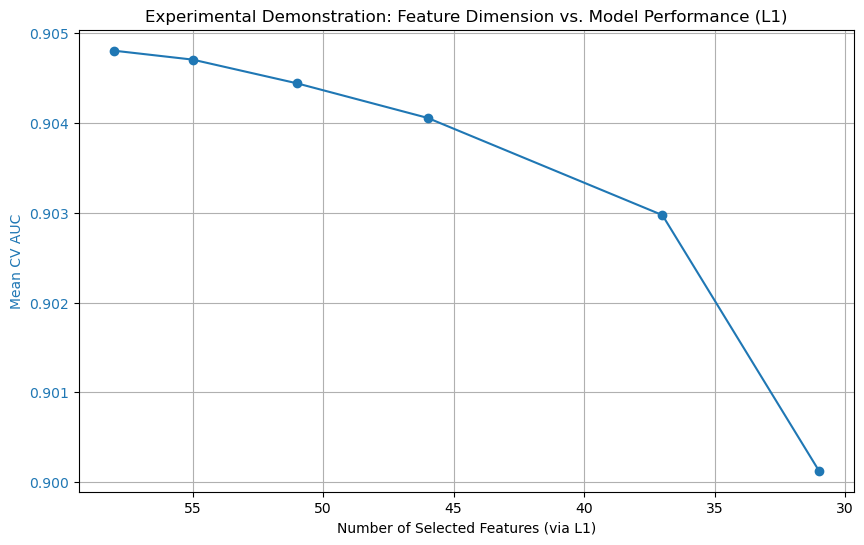

## 成功提取 37 个核心特征
                                              Feature  Coefficient
76  first_careunit_Cardiac Vascular Intensive Care...    -1.720122
84  first_careunit_Neuro Surgical Intensive Care U...     0.712823
82                  first_careunit_Neuro Intermediate    -0.580648
0                                                 age     0.471991
21                                     resp_rate_mean     0.448099
33                                         gcs_verbal    -0.435513
74                             marital_status_Unknown     0.400686
34                                           gcs_eyes    -0.334236
32                                          gcs_motor    -0.284704
9                                     heart_rate_mean     0.265328
25                                           spo2_min    -0.246467
4                                 sofa2_liver_24h_max     0.243400
5                                 sofa2_renal_24h_max     0.215994
65                                       race

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

def l1_feature_selection_path(X_train, y_train):

    c_values = [0.005,0.01, 0.02, 0.03, 0.04, 0.05]
    
    results = []
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for c in c_values:
        # use liblinear solver to support L1 penalty
        # class_weight='balanced' 
        model = LogisticRegression(
            penalty='l1', 
            C=c, 
            solver='liblinear', 
            class_weight='balanced', 
            random_state=42
        )
        
        # cross-validated AUC score
        auc_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
        
        # train full model
        model.fit(X_train, y_train)
        non_zero_count = np.sum(model.coef_ != 0)
        
        results.append({
            'C': c,
            'Selected_Features': non_zero_count,
            'Mean_AUC': auc_scores.mean(),
            'Std_AUC': auc_scores.std()
        })
        
        print(f"C={c:<6} | Selected Features: {non_zero_count:<3} | Mean AUC: {auc_scores.mean():.4f}")


    path_df = pd.DataFrame(results)
    
    # 3. Experimental curve plotting
    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.set_xlabel('Number of Selected Features (via L1)')
    ax1.set_ylabel('Mean CV AUC', color='tab:blue')
    ax1.plot(path_df['Selected_Features'], path_df['Mean_AUC'], marker='o', color='tab:blue', label='AUC')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(True)

    plt.title('Experimental Demonstration: Feature Dimension vs. Model Performance (L1)')
    plt.gca().invert_xaxis()
    plt.show()

    return path_df

# start the L1 feature selection path experiment
X_train_processed = pd.read_csv('X_train_processed.csv', index_col=0)
y_train_processed = pd.read_csv('y_train_processed.csv')['icu_death_flag']

l1_results = l1_feature_selection_path(X_train_processed, y_train_processed)

# 1.use the selected optimal C value to train the final model
best_c = 0.01
final_model = LogisticRegression(
    penalty='l1', 
    C=best_c, 
    solver='liblinear', 
    class_weight='balanced', 
    random_state=42
)
final_model.fit(X_train_processed, y_train_processed)

# 2. Extract feature coefficients
coef_df = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Coefficient': final_model.coef_[0]
})

# 3. 过滤掉被压缩为 0 的特征，并按绝对值排序
selected_features_df = coef_df[coef_df['Coefficient'] != 0].copy()
selected_features_df['Abs_Coefficient'] = selected_features_df['Coefficient'].abs()
selected_features_df = selected_features_df.sort_values(by='Abs_Coefficient', ascending=False)

X_test_processed = pd.read_csv('X_test_processed.csv', index_col=0)

X_train_final = X_train_processed[selected_features_df['Feature']]
X_test_final = X_test_processed[selected_features_df['Feature']]

X_train_final.to_csv('X_train_final.csv', index=True)
X_test_final.to_csv('X_test_final.csv', index=True)

print(f"## 成功提取 {len(selected_features_df)} 个核心特征")
print(selected_features_df[['Feature', 'Coefficient']]) # 查看信号